# SmartCart - E-Commerce Customer Segmentation System

In [49]:
# for ignoring data leakage warning from KMeans
import os
os.environ["OMP_NUM_THREADS"] = "9"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('smartcart_customers.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
print(df.isnull().sum())
df.info()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Inc

# Data Preprocessing

### 1. Handle Missing Values

In [5]:
df['Income']=df['Income'].fillna(df['Income'].median())

In [6]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

### 2. Feature Engineering

In [7]:
# creating age from year_birth
# refernce year -> to make it consistent , if we use 2026 then running the code later will make changes in code and result may become different
reference_year = df['Year_Birth'].max()
df['age'] = reference_year-df['Year_Birth']

In [8]:
# creating customer tenure days from Date of customer joining
# refernce date -> to make it consistent , if we use today's date then running the code next time will make changes in code and result may become different
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'], dayfirst=True)
reference_date = df['Dt_Customer'].max()
df['Customer_Tenure_Days'] = (reference_date - df['Dt_Customer']).dt.days

In [9]:
# merging purchasing columns to total spending
df['Total_Spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [10]:
# merging kidhome and teen home to single column -> total childern
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [11]:
# simplifying education column
df['Education'].value_counts()
df['Education'] = df['Education'].replace({
    'PhD':'Postgraduate', 'Master':'Postgraduate',
    'Graduation':'Graduate',
    '2n Cycle': 'Undergraduate', 'Basic':'Undergraduate'
})

In [12]:
# making feature from Marital Status column -> Living_With - Alone/Partner
df['Marital_Status'].value_counts()
df['Living_With'] = df['Marital_Status'].replace({
    'Married':'Partner', 'Together':'Partner',
    'Single': 'Alone', 'Divorced':'Alone', 'Widow':'Alone', 'Absurd':'Alone', 'YOLO':'Alone'
})

### 3. Drop Unnecessary Columns

In [13]:
cols = ['ID', 'Year_Birth', 'Marital_Status', 'Kidhome', 'Teenhome', 'Dt_Customer']
spending_cols=['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

# Outliers Detection and Handling

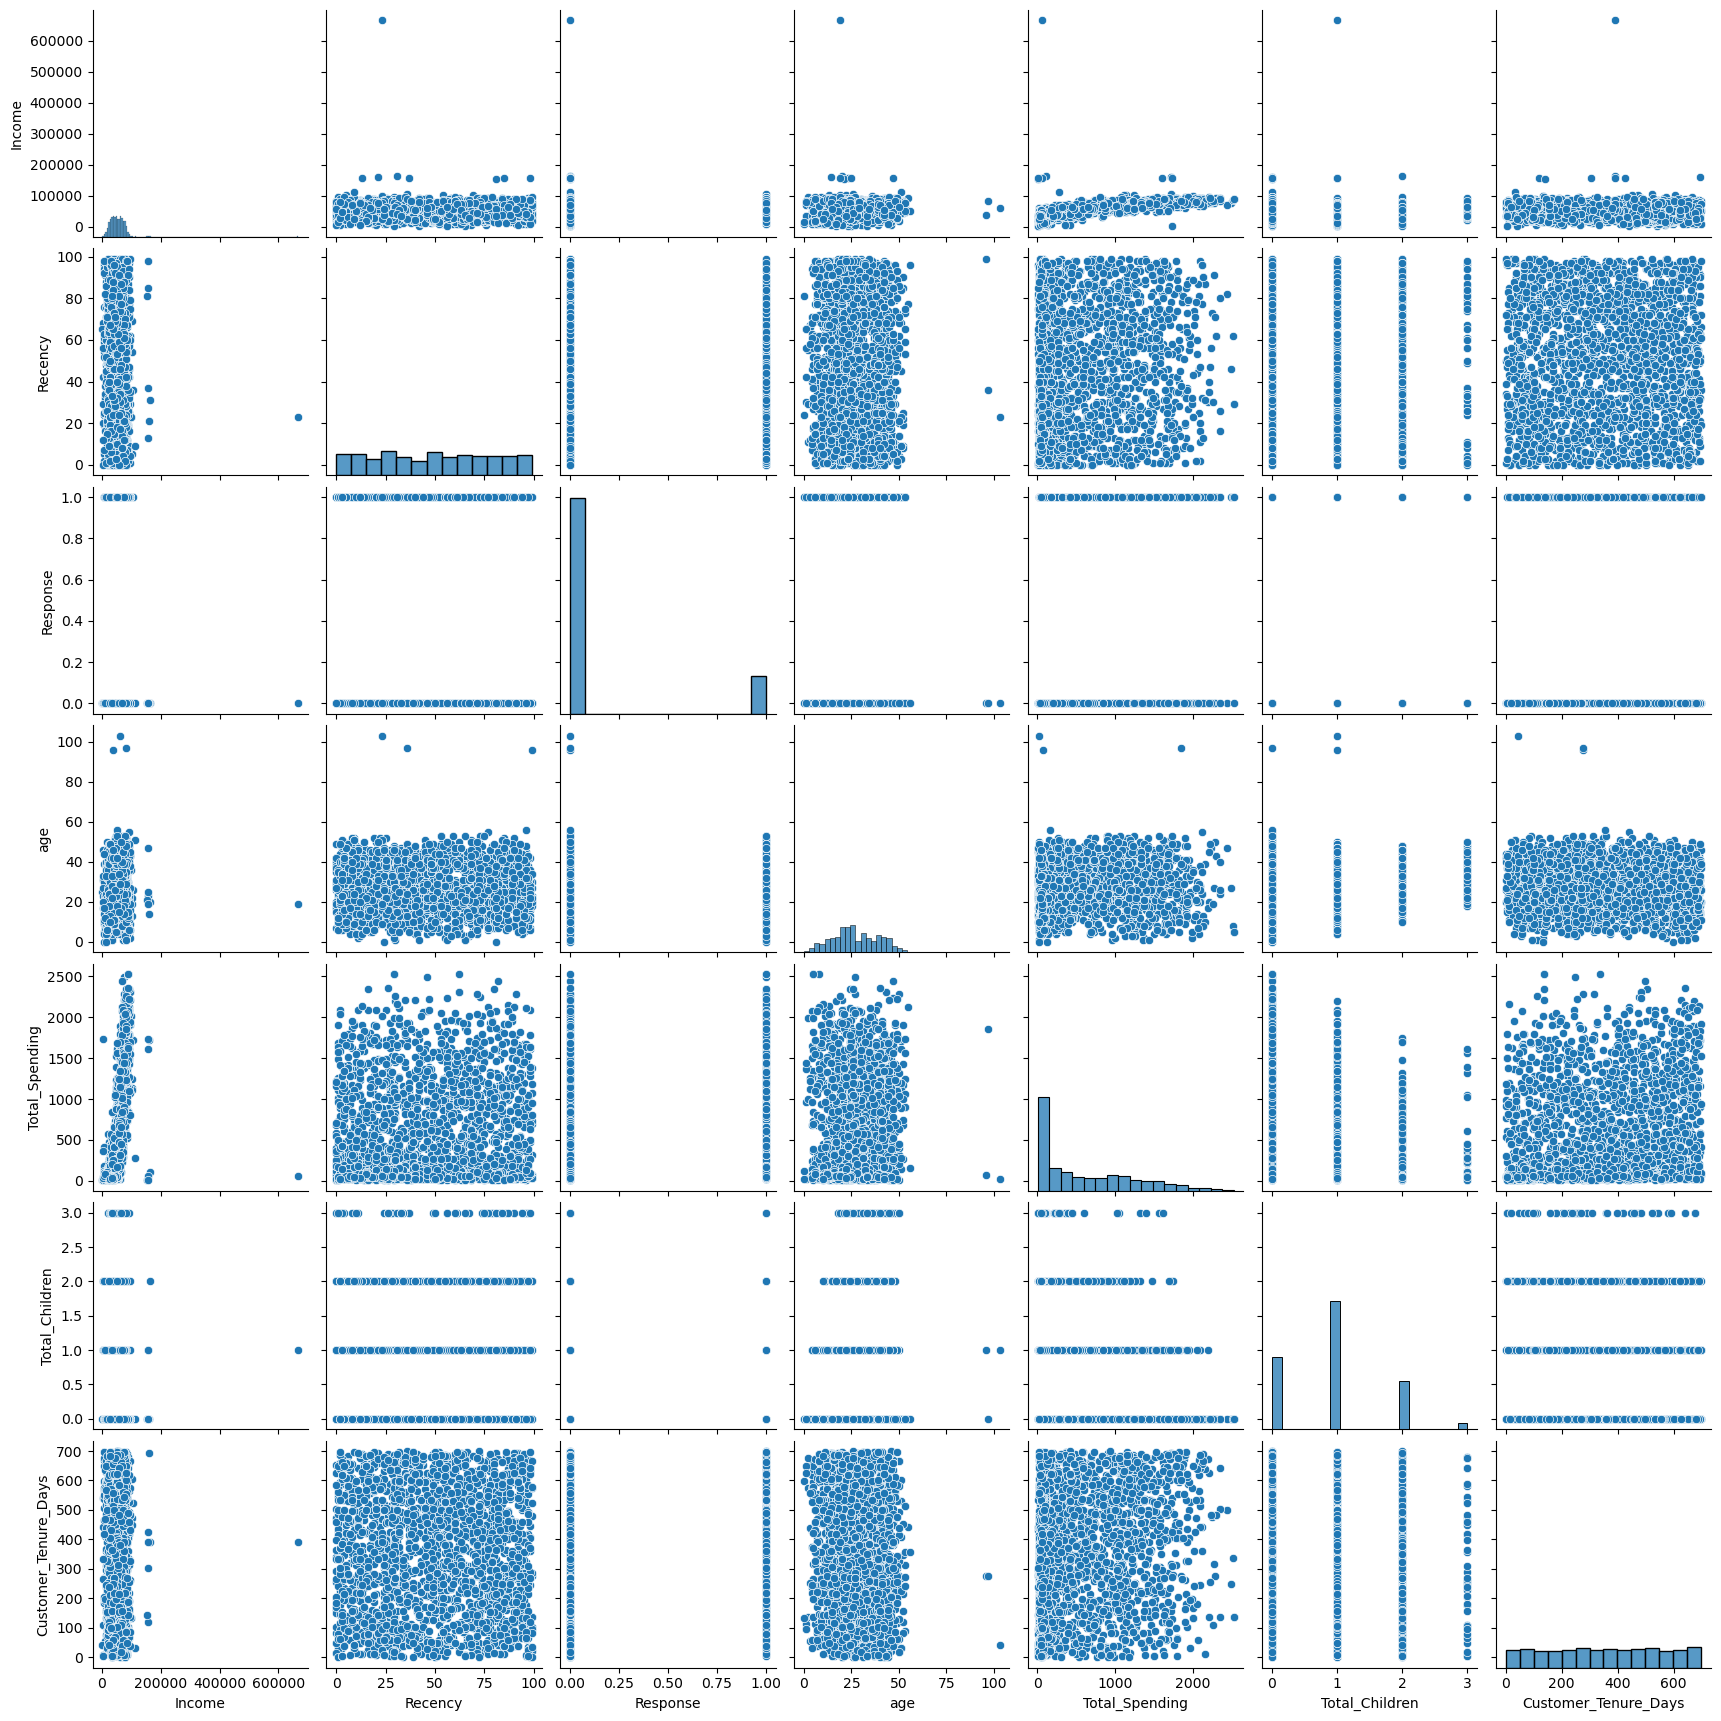

In [14]:
# relative plot of some features -> pairplot
cols=['Income', 'Recency', 'Response', 'age', 'Total_Spending', 'Total_Children', 'Customer_Tenure_Days']
sns.pairplot(df_cleaned[cols])

In [15]:
# remove outliers
print("data size with outliers -> ", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned['age']<80)]
df_cleaned = df_cleaned[(df_cleaned['Income']<600_000)]

print("data size without outliers -> ", len(df_cleaned))

data size with outliers ->  2240
data size without outliers ->  2236


In [16]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_Children',
       'Living_With'],
      dtype='object')

In [17]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,39,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,42,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,31,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,12,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,15,161,422,1,Partner


# Correlation Heatmap

<Axes: >

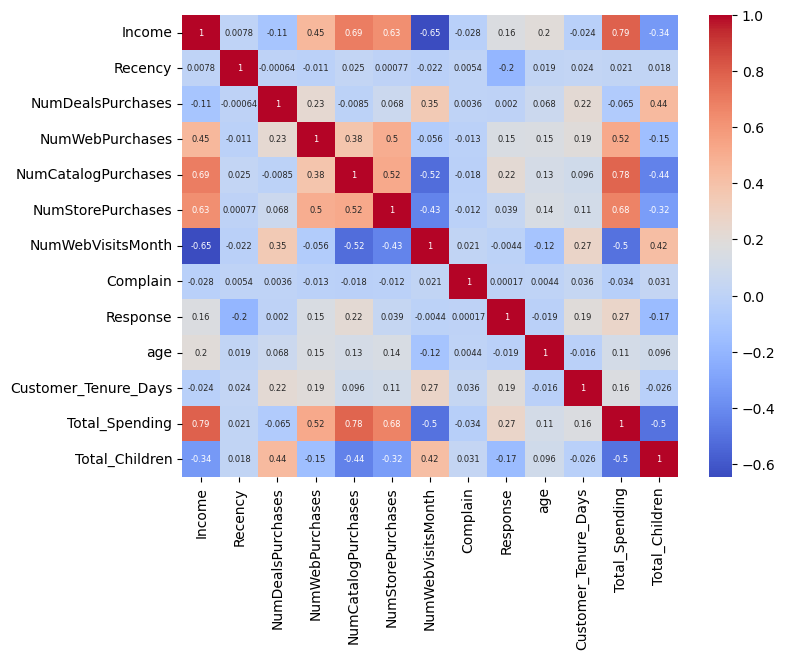

In [18]:
corr = df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={'size':6},
    cmap="coolwarm"
)

# Feature Encoding and Scaling

In [19]:
# feature encoding
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cat_cols = ['Education', 'Living_With']
#clustering does not require drop_first = True , multi-colinearity occurs mainly in linear models
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])
# convert encoded columns in a dataframe
df_enc = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)

#concating df_enc and df_cleaned
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), df_enc], axis=1)

In [20]:
# feature scaling
X = df_encoded
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

# Visualizing Data

array([0.23163158, 0.11385454, 0.10405815])

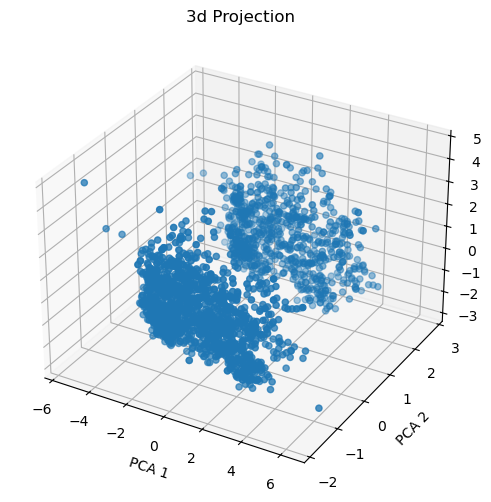

In [21]:
# reduce features for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3d Projection")
#info captured -> 
pca.explained_variance_ratio_

# Clustering

## Choosing Optimal -> K

### 1. Elbow Method

In [22]:
# Elbow Method
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [23]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
print("optimal knee -> ", knee.elbow)

optimal knee ->  4


Text(0, 0.5, 'WCSS')

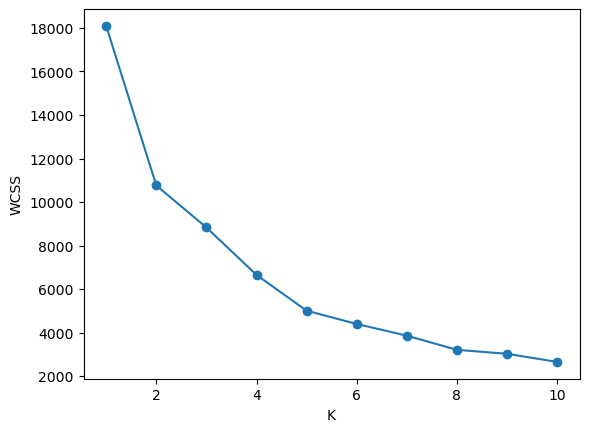

In [24]:
# plot
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

### 2. Silhouette Score

Text(0, 0.5, 'Silhouette Score')

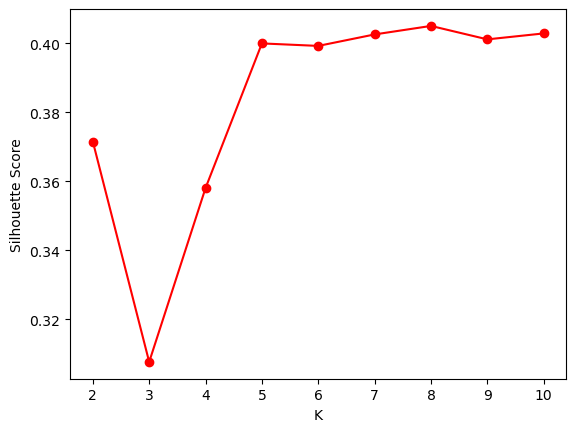

In [33]:
from sklearn.metrics import silhouette_score
scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, labels))
# plot
plt.plot(range(2,11), scores, marker='o', c='r')
plt.xlabel('K')
plt.ylabel('Silhouette Score')

#### combined plot (elbow & Silhouette)

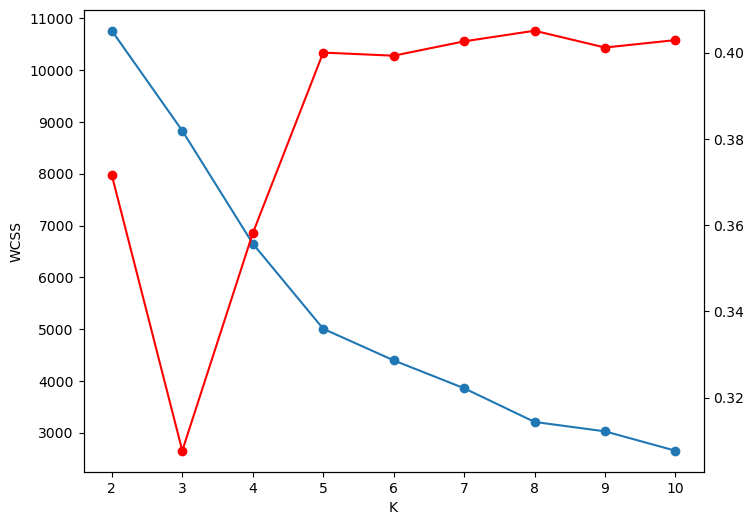

In [48]:
# we usually choose k which is nearest point where elbow method and silhouette score intersects
k_range = range(2,11)
fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[1:], marker='o')
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

# ax2 will use same x-axis with this -> 
ax2 = ax1.twinx()
ax2.plot(k_range, scores, marker='o', c='r')

## Applying KMeans and Agglomerative Clustering

### KMeans

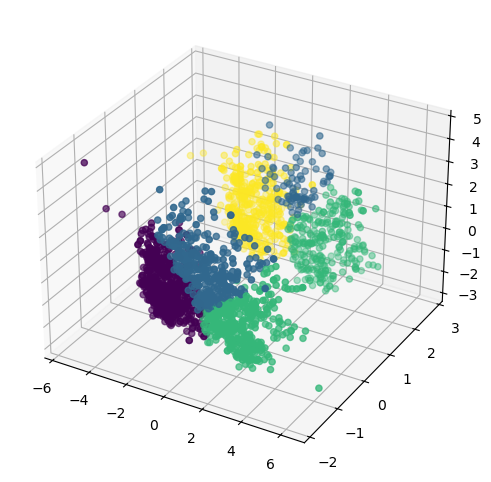

In [51]:
# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_kmeans)

### Agglomerative

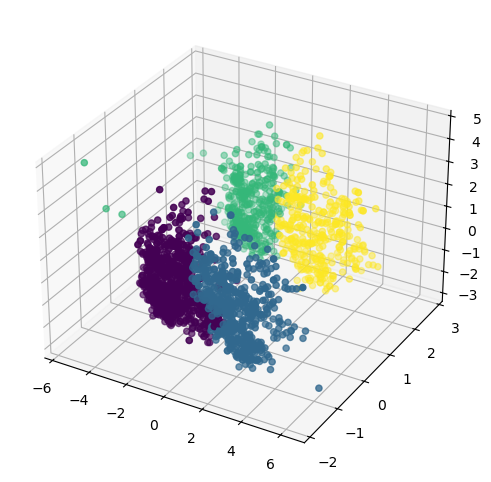

In [78]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = model.fit_predict(X_pca)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_agg)
# it is better so we will use these labels

# Characterization of Clusters

In [66]:
X['Cluster'] = labels_agg

In [67]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Cluster
0,58138.0,58,3,8,10,4,7,0,1,39,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,42,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,31,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,12,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,15,161,422,1,0.0,1.0,0.0,0.0,1.0,0


### Number of customers in each cluster ->

<Axes: xlabel='Cluster', ylabel='count'>

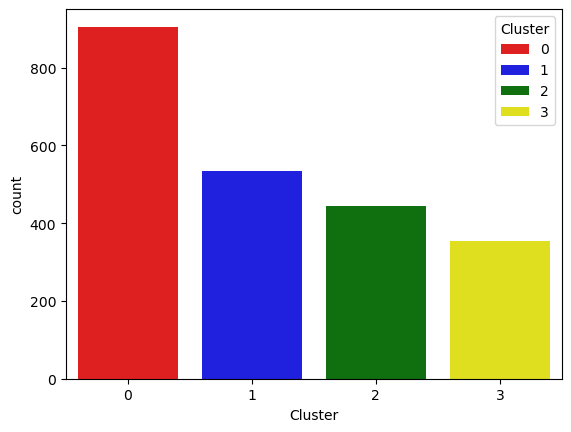

In [69]:
pal = ['red', 'blue', 'green', 'yellow']
sns.countplot(x=X['Cluster'], palette=pal, hue=X['Cluster'])

## now the strongest correlation was income and total spending so we will analyse based on that

<Axes: xlabel='Total_Spending', ylabel='Income'>

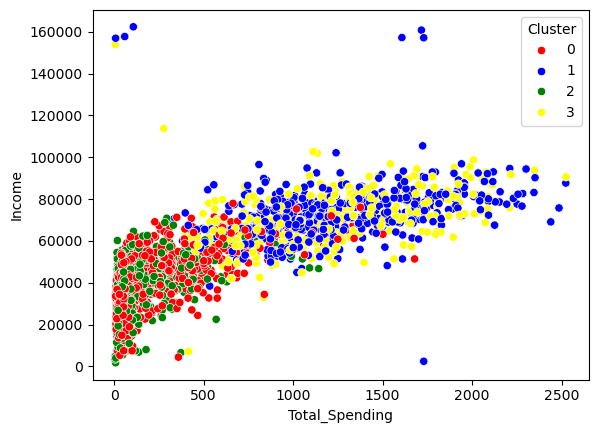

In [71]:
# income and spending patterns
sns.scatterplot(x=X['Total_Spending'], y=X['Income'], hue=X['Cluster'], palette=pal)

## Observation ->
###    0. Cluster - Low-Medium Income and Low-Medium Spending
###    1. Cluster - High Income and High Spending
###    2. Cluster - Low Income and Low Spending
###    3. Cluster - Moderate-High Income and High Spending

# Cluster Summary ->

In [77]:
cluster_summary = X.groupby("Cluster").mean()
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
Cluster,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,25.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,29.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,25.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,28.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000


## 1. Cluster and 3. Cluster are premium customers
## 0. Cluster and 2. Cluster are price sensitive customers

0. cluster propertes ( family customers -> give them more coupon and discounts to increase purchasing frequency) ->
   • more childern
   • less age
   • more deal purchase
   • more web visits
   • low response
   • mostly live with partner

1. cluster propertes ( Premium customers -> give them loyality programs and catalog products) ->
   • less childern
   • more age
   • more catalog purchase
   • less web visits
   • moderate response
   • mostly live with partner

2. cluster propertes ( probably single parent and digital browsers -> target for sales and heavy discounts) ->
   • more childern
   • less age
   • more deal purchase
   • most web visits
   • moderate response
   • mostly live alone

3. cluster propertes ( Premium customers with best response, best ROI, High value singles -> offer them more premium personalized services) ->
   • less childern
   • more age
   • more catalog purchase
   • less web visits
   • best response
   • mostly live alone